## Project Code

In [38]:
# 1. Load the necessary packages
# Data processing
import pandas as pd
import numpy as np
import random as rn

# Standardize the data
from sklearn.preprocessing import StandardScaler

# Modeling 
import tensorflow as tf
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import label_binarize

# Hyperparameter tuning
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, RandomizedSearchCV

# Plot
import matplotlib.pyplot as plt

# Model evaluation
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, auc, roc_auc_score
from sklearn import metrics

from sklearn.model_selection import GroupKFold

In [39]:
#visits=pd.read_excel('Visits_2025-11-05T19_19_03.xlsx')
#peds = visits[visits['Department Specialty'].isin(['Pediatrics', 'Family Practice'])].copy()
visits=pd.read_excel('WELL Visits_2025-11-05T20_18_14.xlsx')
visits = visits[visits['Appointment Status'] == 'Completed'] 

In [40]:
birth=pd.read_excel('Births_2025-04-29T14_27_06.xlsx')

In [41]:
#variable that is true if the baby was discharged later than the mother, false if not
birth['baby_later_discharge']=(birth['Baby Discharge Date'] > birth['Mother Discharge Date']).astype(bool)

#cleaner NICU variable
birth['nicu'] = birth['Baby Was Admitted to ICU?'].notna().astype(bool)

#low birth weight
birth['lbw']=(birth['Birth Weight (g) (g)'] < 2500).astype(bool)

#preterm birth
birth['preterm']=(birth['Gestational Age (Days)'] < 259).astype(bool)

#drop unneeded cols
birth.drop(columns=['Birth Date', 'Birth Weight (g) (g)', 'Baby Was Admitted to ICU?', 'Baby Discharge Date', 'Mother Discharge Date', 'Gestational Age (Days)'], inplace=True) 

In [42]:
birth.rename(columns={'Baby MRN': 'MRN'}, inplace=True)

In [43]:
wcv = pd.merge(visits, birth, on='MRN', how='left')

In [44]:
wcv['has_birth'] = wcv['nicu'].notna().astype(bool)

#fill birth vars with false if missing
bool_vars = ['nicu', 'baby_later_discharge', 'preterm', 'lbw'] 
for col in bool_vars:
    wcv[col] = wcv[col].where(wcv[col].notna(), False).astype(bool)

In [45]:
wcv['Visit Type'].unique()

array(['PEDS COMPLETE', 'PC WELL CHILD', 'PEDS FOLLOW UP', 'PC FOLLOW-UP',
       'FOLLOW-UP VISIT', 'MY OFFICE VISIT', 'MY WELL CHILD EXAM',
       'PC WELL CHILD INTERPRETER', 'PEDS NEW PATIENT', 'NEWBORN',
       'PEDS ACUTE CARE', 'PC OFFICE VISIT', 'PEDS NEWBORN',
       'PC PEDS ESTABLISH CARE', 'PC ACUTE', 'LAB VISIT',
       'PEDS POST HOSPITAL FOLLOW UP', 'MY NEW PATIENT VISIT',
       'PC NEW WELL CHILD', 'PC PEDS PRE-OP', 'MY ILLNESS/INJURY',
       'MY WORKERS COMP', 'NURSE VISIT', 'SAME DAY VISIT',
       'NEW PATIENT VISIT', 'OV10', 'PC FOLLOW-UP INTERPRETER',
       'AUDIO BRAINSTEM RESPONSE', 'IL XR BONE SURVEY INFANT',
       'PC NEW WELL CHILD INTERP', 'PC PEDS EST CARE INTERPRETER',
       'COMPLETE PHYSICAL EXAM', 'PC NEW ACUTE', 'WELL CHILD EXAM',
       'PC TCM', 'OFFICE VISIT', 'PC OFFICE VISIT INTERPRETER',
       'PEDS PRE-OP VISIT', 'LAB WALK IN', 'AUDIOGRAM',
       'PC EXTENDED OFFICE VISIT', 'LAB ON MY WAY',
       'IL US HIPS BILATERAL INFANT WITH MANIPULA

In [46]:
# List of visit types to exclude
exclude_types = [
    'MY WORKERS COMP', 'IL US HIPS BILATERAL INFANT WITH MANIPULATION', 'LAB VISIT', 'LAB WALK IN',
    'AUDIOGRAM', 'LAB ON MY WAY', 'IL XR ANKLE LT MIN 3V', 'IL XR FOOT LT MIN 3V', 'WALK-IN VISIT',
    'IL XR BONE SURVEY INFANT', 'AUDIO BRAINSTEM RESPONSE', 'NURSE VISIT'
]

# Drop rows where Visit Type is in the exclude list
wcv = wcv[~wcv['Visit Type'].isin(exclude_types)]

In [47]:
wcv.head()

,MRN,Visit Date,Department,Interpreter Needed?,Weight (lb),Appointment Status,Patient Sex,Language,Patient Birth Date,Lead Time (days),...,New to Department?,Primary Payer Financial Class,Age in Months (At Visit) (months),Primary Diagnosis Code ICD-10-CM,Department Specialty,baby_later_discharge,nicu,lbw,preterm,has_birth
0,12240902,2022-03-08,ADMG EVERGREEN PLAZA 9730 WEST PED,0,12.268750,Completed,Female,English,2022-01-02,7.0,...,0.0,Medicaid Other,2,Z23,Pediatrics,False,False,False,False,True
1,12240902,2022-08-09,ADMG EVERGREEN PLAZA 9730 WEST PED,0,18.783125,Completed,Female,English,2022-01-02,33.0,...,0.0,Medicaid Other,7,Z23,Pediatrics,False,False,False,False,True
2,12240902,2023-02-24,ADMG EVERGREEN PLAZA 9730 WEST PED,0,22.486875,Completed,Female,English,2022-01-02,3.0,...,0.0,Medicaid Other,13,Z01.89,Pediatrics,False,False,False,False,True
3,12240902,2023-08-15,ADMG EVERGREEN PLAZA 9730 WEST PED,0,25.242500,Completed,Female,English,2022-01-02,56.0,...,0.0,Medicaid Other,19,Z23,Pediatrics,False,False,False,False,True
4,12240992,2022-03-01,ADMG EVERGREEN PLAZA 9730 WEST PED,0,10.306250,Completed,Male,English,2022-01-01,29.0,...,0.0,Medicaid Other,2,Z00.129,Pediatrics,False,False,False,False,True


In [48]:
#Identify clinics in sample
wcv['sample'] = wcv['Department'].isin([
    "ADMG OAK LAWN 4220 95TH S 210 PED",
    "ADMG OAK LAWN 4700 95TH S303 PED",
    "ADMG PARK RIDGE 1675 DEMPSTER PED",
    "ADMG EVERGREEN PLAZA 9730 WEST PED",
    "ADMG DES PLAINES 77 RAND RD PED",
    "ADMG DES PLAINES 77 RAND RD FP"
]).astype(int)

In [49]:
# Define the mapping function
def map_wcv(age):
    if 0 <= age < 1:
        return 0
    elif 1 <= age < 2:
        return 1
    elif 2 <= age < 4:
        return 2
    elif 4 <= age < 6:
        return 4
    elif 6 <= age < 9:
        return 6
    elif 9 <= age < 12:
        return 9
    elif 12 <= age < 15:
        return 12
    elif 15 <= age < 24:
        return 15
    else:
        return None  # For negative ages or missing data

wcv.rename(columns={'Age in Months (At Visit) (months)': 'age_months'}, inplace=True)
wcv['timepoint'] = wcv['age_months'].apply(map_wcv)

# Sort by MRN and Visit Date
wcv = wcv.sort_values(by=['MRN', 'Visit Date'])

# Define the standard timepoints in order
timepoints_order = [0, 1, 2, 4, 6, 9, 12, 15, 24]

# Create a mapping for next expected timepoint
next_tp_map = {tp: timepoints_order[i+1] if i+1 < len(timepoints_order) else None
               for i, tp in enumerate(timepoints_order)}

# Compute next timepoint for each row
wcv['next_expected_wcv'] = wcv['timepoint'].map(next_tp_map)

# Check if patient has that next timepoint anywhere
wcv['has_next_wcv'] = wcv.apply(
    lambda row: row['next_expected_wcv'] in wcv.loc[wcv['MRN'] == row['MRN'], 'timepoint'].values,
    axis=1
)

In [50]:
# Impute missing weight using median of same timepoint
wcv.rename(columns={'Weight (lb)': 'weight_lb'}, inplace=True)
wcv['weight_lb'] = wcv['weight_lb'].fillna(
    wcv.groupby('timepoint')['weight_lb'].transform('median')
)

In [51]:
#recode insurance to medicaid, commercial, self-pay
wcv.rename(columns={'Primary Payer Financial Class': 'insurance'}, inplace=True)
wcv['insurance'] = wcv['insurance'].where(
    wcv['insurance'].isin(['Medicaid', 'Medicaid Other', 'Self-Pay']),
    'Commercial'
    ).replace({
    'Medicaid Other': 'Medicaid'
    }).astype('category')

#recode language
wcv.rename(columns={'Language': 'language'}, inplace=True)
wcv['language'] = wcv['language'].where(
    wcv['language'].isin(['English', 'Spanish']),
    'Another Language'
    ).astype('category')

#recode race
wcv.rename(columns={'OMB Race': 'race'}, inplace=True)
wcv['race'] = wcv['race'].where(
    wcv['race'].isin(['White', 'Black or African American', 'Asian', 'Asked but No Answer', 'Unknown']),
    'Another Race'
    ).replace({
    'Asked but No Answer': 'Not Reported',  'Unknown': 'Not Reported', 'Black or African American': 'Black'
    }).astype('category')

#recode ethnicity
wcv.rename(columns={'OMB Ethnicity': 'ethnicity'}, inplace=True)
wcv['ethnicity'] = wcv['ethnicity'].where(
    wcv['ethnicity'].isin(['Not Hispanic or Latino', 'Hispanic or Latino']),
    'Not Reported'
    ).astype('category')

#recode provider type
wcv.rename(columns={'Primary Provider Type': 'provider_type'}, inplace=True)
wcv['provider_type'] = wcv['provider_type'].where(
    wcv['provider_type'].isin(['Physician', 'Nurse Practitioner']),
    'Resident/Fellow'
    ).astype('category')

In [52]:
# Convert to desired types
wcv = wcv.astype({
    'Department': 'category',
    'Interpreter Needed?': 'bool',
    'Appointment Status': 'category',
    'Patient Sex': 'category',
    'Confirmed?': 'bool',
    'Day of Week': 'category',
    'Portal Active at Scheduling?': 'bool',
    'New to Department?': 'bool',
    'Department Specialty': 'category'
})
wcv['Lead Time (days)'] = wcv['Lead Time (days)'].astype('Int64')

wcv.rename(columns={'Portal Active at Scheduling?': 'portal_active'}, inplace=True)


In [53]:
# Drop rows where timepoint > 12 and outside included clinic
wcv = wcv[wcv['timepoint'] <= 12]
wcv = wcv[wcv['sample'] == 1]

In [54]:
# Sort by MRN, timepoint, and Visit Date so earliest dates come first
wcv = wcv.sort_values(by=['MRN', 'timepoint', 'Visit Date'], ascending=[True, True, True])

# Drop duplicates, keeping the first (earliest Visit Date)
wcv = wcv.drop_duplicates(subset=['MRN', 'timepoint'], keep='first')

In [55]:
wcv['has_next_wcv'].value_counts()

has_next_wcv
True     5403
False    1295
Name: count, dtype: int64

In [56]:
print(wcv.columns.tolist())

['MRN', 'Visit Date', 'Department', 'Interpreter Needed?', 'weight_lb', 'Appointment Status', 'Patient Sex', 'language', 'Patient Birth Date', 'Lead Time (days)', 'Confirmed?', 'Late Cancel?', 'Day of Week', 'BMI (kg/m^2)', 'portal_active', 'Appointment Confirmation Status', 'eCheck-In Status', 'provider_type', 'race', 'ethnicity', 'Visit Type', 'New to Department?', 'insurance', 'age_months', 'Primary Diagnosis Code ICD-10-CM', 'Department Specialty', 'baby_later_discharge', 'nicu', 'lbw', 'preterm', 'has_birth', 'sample', 'timepoint', 'next_expected_wcv', 'has_next_wcv']


In [57]:
wcv.drop(['Department', 'Visit Type', 'Visit Date', 'Appointment Status', 'Patient Birth Date', 'Confirmed?', 'Late Cancel?', 'Appointment Confirmation Status', 'eCheck-In Status', 'BMI (kg/m^2)', 'Primary Diagnosis Code ICD-10-CM', 'Department Specialty', 'sample', 'next_expected_wcv'], axis=1, inplace=True)

In [58]:
wcv.rename(columns={'Interpreter Needed?': 'interpreter'}, inplace=True)
wcv.rename(columns={'Patient Sex': 'sex'}, inplace=True)
wcv.rename(columns={'Lead Time (days)': 'sch_lead_days'}, inplace=True)
wcv.rename(columns={'Day of Week': 'day_of_week'}, inplace=True)
wcv.rename(columns={'New to Department?': 'new_to_dpt'}, inplace=True)

In [59]:
wcv.dtypes

MRN                        int64
interpreter                 bool
weight_lb                float64
sex                     category
language                category
sch_lead_days              Int64
day_of_week             category
portal_active               bool
provider_type           category
race                    category
ethnicity               category
new_to_dpt                  bool
insurance               category
age_months                 int64
baby_later_discharge        bool
nicu                        bool
lbw                         bool
preterm                     bool
has_birth                   bool
timepoint                  int64
has_next_wcv                bool
dtype: object

In [60]:
wcv['timepoint'] = wcv['timepoint'].astype('category')
wcv = pd.DataFrame(pd.get_dummies(wcv, columns=['sex', 'language', 'day_of_week', 'provider_type', 'race', 'ethnicity', 'insurance', 'timepoint']))

In [61]:
wcv.dtypes

MRN                                   int64
interpreter                            bool
weight_lb                           float64
sch_lead_days                         Int64
portal_active                          bool
new_to_dpt                             bool
age_months                            int64
baby_later_discharge                   bool
nicu                                   bool
lbw                                    bool
preterm                                bool
has_birth                              bool
has_next_wcv                           bool
sex_Female                             bool
sex_Male                               bool
language_Another Language              bool
language_English                       bool
language_Spanish                       bool
day_of_week_Friday                     bool
day_of_week_Monday                     bool
day_of_week_Saturday                   bool
day_of_week_Thursday                   bool
day_of_week_Tuesday             

In [62]:
print(wcv.columns.tolist()) 

['MRN', 'interpreter', 'weight_lb', 'sch_lead_days', 'portal_active', 'new_to_dpt', 'age_months', 'baby_later_discharge', 'nicu', 'lbw', 'preterm', 'has_birth', 'has_next_wcv', 'sex_Female', 'sex_Male', 'language_Another Language', 'language_English', 'language_Spanish', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'provider_type_Nurse Practitioner', 'provider_type_Physician', 'provider_type_Resident/Fellow', 'race_Another Race', 'race_Asian', 'race_Black', 'race_Not Reported', 'race_White', 'ethnicity_Hispanic or Latino', 'ethnicity_Not Hispanic or Latino', 'ethnicity_Not Reported', 'insurance_Commercial', 'insurance_Medicaid', 'insurance_Self-Pay', 'timepoint_0', 'timepoint_1', 'timepoint_2', 'timepoint_4', 'timepoint_6', 'timepoint_9', 'timepoint_12']


In [63]:
# Random Forest
######################################################################################

# 3. Data split and standardization

# fix random seed for reproducibility
seed = 123

# # The below is necessary for starting Numpy generated random numbers
# # in a well-defined initial state.
np.random.seed(seed)

# # The below is necessary for starting core Python generated random numbers
# # in a well-defined state.
rn.seed(seed)

# Train (80%) and test (20%) set split
# Make separate data set for Y and X
Y_df = wcv['has_next_wcv']
X_df = wcv.drop(['has_next_wcv'], axis=1)

print(f'The dependent (Y) dataset has {Y_df.shape}.')
print(f'The independent (X) dataset has {X_df.shape}.')

The dependent (Y) dataset has (6698,).
The independent (X) dataset has (6698, 44).


In [64]:
######SPLIT ON MRN#####
# Step 1: Get unique MRNs
unique_mrns = X_df['MRN'].unique()

# Step 2: Split MRNs into train and test sets
mrn_train, mrn_test = train_test_split(unique_mrns, test_size=0.2, random_state=42)

# Step 3: Filter rows based on MRN
X_train = X_df[X_df['MRN'].isin(mrn_train)]
X_test = X_df[X_df['MRN'].isin(mrn_test)]
y_train = Y_df.loc[X_train.index]
y_test = Y_df.loc[X_test.index]

#drop MRN so it isn't included as a feature
X_train = X_train.drop(columns=['MRN']).copy()
X_test = X_test.drop(columns=['MRN']).copy()

# Check the number of records in training and testing dataset.
print(f'The training dataset has {len(X_train)} records.')
print(f'The testing dataset has {len(X_test)} records.')

# Standardization of continuous variable.
# VERY IMPORTANT: to avoide any information leaking from testing data to training data, we do standardization separately. 
# define continuous variable columns
X_train_c = X_train[['weight_lb', 'sch_lead_days', 'age_months']]
X_test_c = X_test[['weight_lb', 'sch_lead_days', 'age_months']]

#standardize the values for each predictor variable
X_train[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']] = (X_train_c-X_train_c.mean())/X_train_c.std()
X_test[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']] = (X_test_c-X_test_c.mean())/X_test_c.std()

# drop the original continuous variables
X_train = X_train.drop(['weight_lb', 'sch_lead_days', 'age_months'], axis=1)
X_test = X_test.drop(['weight_lb', 'sch_lead_days', 'age_months'], axis=1)

# View mean after the standardization
print(X_train[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']].mean())
print(X_train[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']].std())

# View mean after the standardization
print(X_train[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']].mean())
print(X_train[['weight_lb_s', 'sch_lead_days_s', 'age_months_s']].std())

# Check the number of records in training and testing dataset.
print(f'The training dataset has {len(X_train)} records after standardization.')
print(f'The testing dataset has {len(X_test)} records after standardization.')

# Print the dimension of data
print(f'The training dataset has {X_train.shape}.')
print(f'The testing dataset has {X_test.shape}.')

The training dataset has 5332 records.
The testing dataset has 1366 records.
weight_lb_s        0.0
sch_lead_days_s   -0.0
age_months_s      -0.0
dtype: Float64
weight_lb_s        1.0
sch_lead_days_s    1.0
age_months_s       1.0
dtype: Float64
weight_lb_s        0.0
sch_lead_days_s   -0.0
age_months_s      -0.0
dtype: Float64
weight_lb_s        1.0
sch_lead_days_s    1.0
age_months_s       1.0
dtype: Float64
The training dataset has 5332 records after standardization.
The testing dataset has 1366 records after standardization.
The training dataset has (5332, 43).
The testing dataset has (1366, 43).


Before OverSampling, counts of label '1 (Yes)': 4274
Before OverSampling, counts of label '0 (No)': 1058 

After OverSampling, the shape of train_X: (8548, 43)
After OverSampling, the shape of train_y: (8548,) 

After OverSampling, counts of label '1': 4274
After OverSampling, counts of label '0': 4274
Fitting 10 folds for each of 2 candidates, totalling 20 fits
The best parameters are {'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 4, 'max_depth': 20}
Sensitivity: 0.82
Specificity: 0.35
Accuracy: 0.74


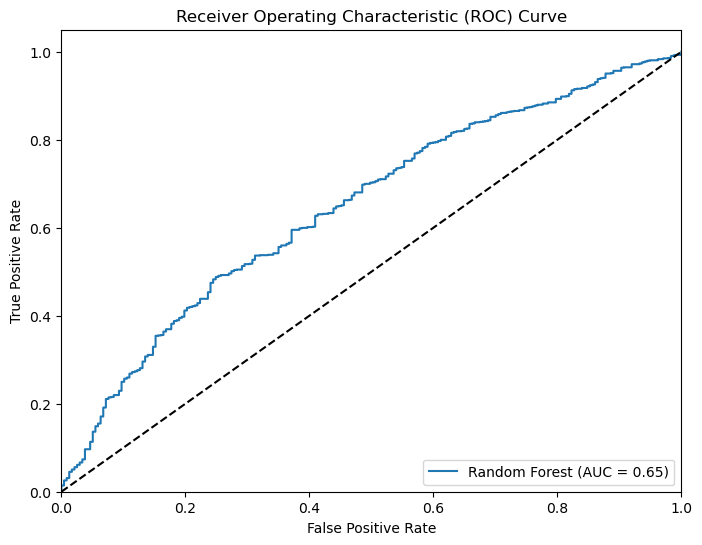

In [66]:


######################################################################################
# 4. Model building
rf = RandomForestClassifier(n_jobs=-1)
'''
# Hyperparameter search for RF.
rf_param_grid = {
    'max_depth': [20, 30, 50, 100],
    'max_features': [2, 3, 4, 5, 8, 10],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [3, 4, 5, 10, 15],
    'n_estimators': [100, 200, 300, 500, 800, 1000]
    }

# Instantiate the grid search model
rf_grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,  
    n_iter=50, 
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
'''
##### Simple specs to troubleshooting####
# Hyperparameter search for RF.
rf_param_grid = {
    'max_depth': [20],
    'max_features': [2, 4],
    'min_samples_leaf': [3],
    'min_samples_split': [3],
    'n_estimators': [100]
    }

# Instantiate the grid search model
rf_grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,  
    n_iter=2, 
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
######




# Synthetic Minority Oversampling Technique (SMOTE) in training data
sm = SMOTE(random_state=42)
x_train_s, y_train_s = sm.fit_resample(X_train, y_train)

# Print before SMOTE
print("Before OverSampling, counts of label '1 (Yes)': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0 (No)': {} \n".format(sum(y_train == 0)))
  
# Print after SMOTE
print('After OverSampling, the shape of train_X: {}'.format(x_train_s.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_s.shape))
  
print("After OverSampling, counts of label '1': {}".format(sum(y_train_s == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_s == 0)))

# Fit the model using training data after SMOTE
rf_grid_search.fit(x_train_s, y_train_s)

rf_best_grid = rf_grid_search.best_estimator_
rf_best_params = rf_grid_search.best_params_
######################################################################################
# 5. Model evaluation and plotting

#define metrics
#y_pred_proba = rf_best_grid.predict(X_test)
#y_pred_proba = rf_best_grid.predict(X_test)[:, 1]
#fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)

# Calculate the area under the ROC curve (AUC)
#roc_auc = auc(fpr, tpr)

yscore_raw = rf_best_grid.predict_proba(X_test)
yscore = [s[1] for s in yscore_raw]
fpr, tpr, thresh = roc_curve(y_test, yscore)
#auc = roc_auc_score(y_test, yscore)

# Calculate the area under the ROC curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Plot the random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig('Random_Forest_MOF.png')

# print the best hyperparameters
print(f'The best parameters are {rf_best_params}')

#The best parameters are {'max_depth': 20, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 500}

y_hat = rf_best_grid.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_hat)

# Extract the true positives, true negatives, false positives, and false negatives
tn, fp, fn, tp = cm.ravel()

# Calculate sensitivity (true positive rate)
sensitivity = tp / (tp + fn)

# Calculate specificity (true negative rate)
specificity = tn / (tn + fp)

# Calculate accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Print the sensitivity, specificity, and accuracy
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Accuracy: {accuracy:.2f}")

In [67]:
# After fitting the model
import pandas as pd

# Get feature importances from the best model
importances = rf_best_grid.feature_importances_

# Combine with feature names
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                             Feature  Importance
42                      age_months_s    0.138719
41                   sch_lead_days_s    0.125327
40                       weight_lb_s    0.113797
31                insurance_Medicaid    0.029591
13                day_of_week_Friday    0.025793
24                        race_Black    0.025741
37                       timepoint_6    0.025486
2                         new_to_dpt    0.025010
18             day_of_week_Wednesday    0.024440
14                day_of_week_Monday    0.024130
20           provider_type_Physician    0.022958
26                        race_White    0.022663
33                       timepoint_0    0.022451
7                          has_birth    0.022398
1                      portal_active    0.021221
8                         sex_Female    0.021174
16              day_of_week_Thursday    0.021066
39                      timepoint_12    0.020719
9                           sex_Male    0.020028
17               day

<Figure size 1000x600 with 0 Axes>

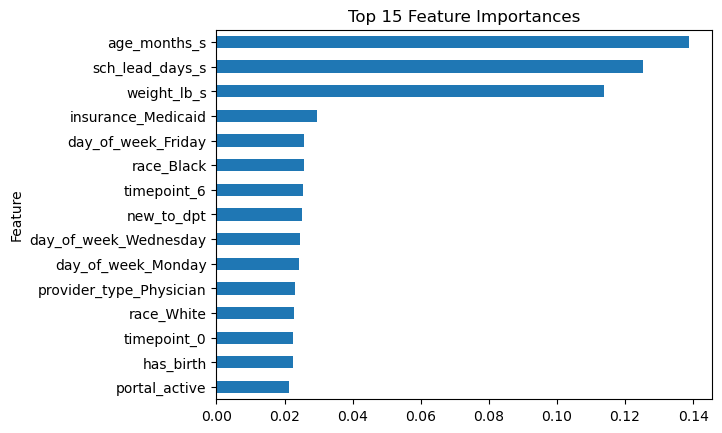

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
importance_df.head(15).plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [579]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_best_grid, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({'Feature': X_test.columns, 'Importance': result.importances_mean})
perm_df = perm_df.sort_values(by='Importance', ascending=False)

print(perm_df.head(15))

                             Feature  Importance
5                           sex_Male    0.045974
30                       timepoint_1    0.036603
27                insurance_Medicaid    0.035359
24  ethnicity_Not Hispanic or Latino    0.034700
23      ethnicity_Hispanic or Latino    0.034407
4                         sex_Female    0.033821
26              insurance_Commercial    0.029722
22                        race_White    0.026061
31                       timepoint_2    0.025915
33                       timepoint_6    0.025183
38                      age_months_s    0.022767
20                        race_Black    0.019693
10                day_of_week_Monday    0.017423
16           provider_type_Physician    0.016984
17     provider_type_Resident/Fellow    0.015739
